In [6]:
# Cel (22.08.2026, pomysl Maćka - patrz zrodla/Maciej Flaga Praktyki 2026.txt,
# wpis 22.08, akapit o wykresie fazy): wykres fazy z 20260822d.ipynb pokazal,
# ze optymalne t0 najczesciej wypada albo na POCZATKU cyklu (2-4 pierwsze
# lata) albo na KONCU cyklu (8-12 ostatnich lat) - PRAWIE NIGDY w srodku.
# To sugeruje, ze prawdziwe "klastry" leza na PRZEJSCIACH miedzy cyklami
# (minimach slonecznych), a nasz dotychczasowy podzial na cykle [minimum_i,
# minimum_i+1) rozcina te klastry na pol miedzy dwa sasiednie kubelki (co
# widac np. w tym, ze cycle_1996 I cycle_2008 mialy podwyzszona liczbe
# "gwiazdek" - prawdopodobnie ten sam klaster 2006-2009 policzony w dwoch
# miejscach).
#
# Test: przegrupowac te same, JUZ POLICZONE dane (results/cycle_scan_*.csv -
# PELNE krzywe PPDF-vs-t0 per kandydat, nie tylko ekstrema) wedlug segmentow
# PRZESUNIETYCH o pol cyklu w fazie - czyli wyznaczonych przez MAKSIMA
# sloneczne (szczyty cykli) zamiast minima. Kazdy nowy segment jest wtedy
# WYSRODKOWANY na jednym z oryginalnych przejsc (minimum), zamiast miec je
# na brzegu. ZERO nowych obliczen NMDB/skanu - to czyste przegrupowanie
# istniejacych wynikow, bezpieczne/tanie.
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from statsmodels.nonparametric.smoothers_lowess import lowess

RESULTS_DIR = "../results"
HOMOLA_LOG10_PPDF_BENCHMARK = -8

STATION_NAMES = sorted(
    ["mosc", "oulu", "athn", "hrms", "sopb", "thul", "lmks", "apty", "jung1",
     "sopo", "fsmt", "jung", "newk", "pwnk", "mxco", "nain", "tera", "invk",
     "aatb", "psnm", "nanm", "mcrl"],
    key=len, reverse=True,
)
FILENAME_RE = re.compile(r"^(?P<cycle>cycle_\d{4}(?:_incomplete)?)_P(?P<Pdays>\d+)_d(?P<d>\d+)$")


def parse_result_filename(path):
    base = os.path.basename(path)
    if not (base.startswith("cycle_scan_") and base.endswith(".csv")):
        return None
    rest = base[len("cycle_scan_"):-len(".csv")]
    station = next((s for s in STATION_NAMES if rest.startswith(s + "_")), None)
    if station is None:
        return None
    m = FILENAME_RE.match(rest[len(station) + 1:])
    if not m:
        return None
    return dict(station=station, P_days=int(m["Pdays"]), d=int(m["d"]))


# Wczytanie WSZYSTKICH kandydatow (nie tylko ekstremow) ze wszystkich
# oryginalnych plikow cyklowych - konkatenacja daje jedna ciagla krzywa
# PPDF-vs-t0 per stacja/P_days/d na calym dostepnym zakresie (oryginalne
# cykle byly ciagle, bez przerw/nakladania), gotowa do przeciecia na nowo
# dowolnymi granicami.
frames = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv"))):
    meta = parse_result_filename(path)
    if meta is None:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF", "sigma", "Np", "Nm"], parse_dates=["t0"])
    df = df.dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    df["P_days"] = meta["P_days"]
    df["d"] = meta["d"]
    frames.append(df)

all_candidates = pd.concat(frames, ignore_index=True)
print(f"Wczytano {len(all_candidates)} wierszy (wszyscy kandydaci, wszystkie stacje/P_days/d) z {len(frames)} plikow")
print(f"Zakres t0: {all_candidates['t0'].min()} .. {all_candidates['t0'].max()}")


Wczytano 1206908 wierszy (wszyscy kandydaci, wszystkie stacje/P_days/d) z 384 plikow
Zakres t0: 1965-01-02 00:00:00 .. 2020-07-01 00:00:00


Wykryte maksima cykli slonecznych (25) - nowe granice segmentow:
  1750-04-01
  1761-06-01
  1770-06-01
  1778-11-01
  1788-03-01
  1804-06-01
  1816-07-01
  1837-06-01
  1848-07-01
  1860-03-01
  1870-12-01
  1883-10-01
  1893-10-01
  1906-04-01
  1918-03-01
  1927-11-01
  1937-11-01
  1948-02-01
  1958-05-01
  1968-11-01
  1980-05-01
  1990-04-01
  2001-12-01
  2014-03-01
  2024-11-01


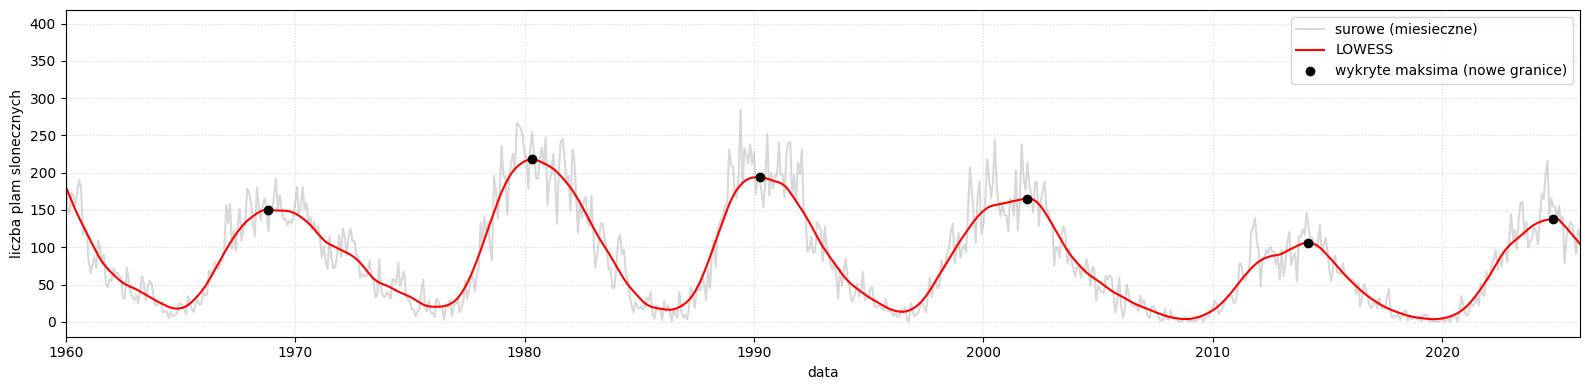


6 przesunietych segmentow:
  shift_1958: 1965-01-02 .. 1968-11-01 (3.8 lat)
  shift_1968: 1968-11-01 .. 1980-05-01 (11.5 lat)
  shift_1980: 1980-05-01 .. 1990-04-01 (9.9 lat)
  shift_1990: 1990-04-01 .. 2001-12-01 (11.7 lat)
  shift_2001: 2001-12-01 .. 2014-03-01 (12.2 lat)
  shift_2014: 2014-03-01 .. 2020-07-01 (6.3 lat)


In [7]:
# Granice PRZESUNIETE o pol cyklu: MAKSIMA sloneczne (nie minima jak w
# 20260822c.ipynb) - ta sama LOWESS (frac=0.01), find_peaks na sygnale WPROST
# (nie odwroconym), te same distance/prominence dla spojnosci. Kazdy nowy
# segment [maks_i, maks_i+1) jest wysrodkowany na JEDNYM oryginalnym minimum
# (przejsciu miedzy cyklami).
sn = pd.read_csv("../data/SN_m_tot_V2.0.csv", sep=";")
sn.columns = [c.strip() for c in sn.columns]
sn["date"] = pd.to_datetime(dict(year=sn["rok"], month=sn["miesiac"], day=1))
smoothed = lowess(sn["sunspot"].values, sn["rok_norm"].values, frac=0.01)[:, 1]

max_idx, _ = find_peaks(smoothed, distance=100, prominence=5)
shift_dates = pd.to_datetime(sn["date"].values[max_idx])

print(f"Wykryte maksima cykli slonecznych ({len(shift_dates)}) - nowe granice segmentow:")
for d in shift_dates:
    print(f"  {d.date()}")

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(sn["date"], sn["sunspot"], color="gray", alpha=0.3, label="surowe (miesieczne)")
ax.plot(sn["date"], smoothed, color="red", label="LOWESS")
ax.plot(shift_dates, smoothed[max_idx], "o", color="black", label="wykryte maksima (nowe granice)")
ax.set_xlim(pd.Timestamp("1960-01-01"), pd.Timestamp("2026-01-01"))
ax.set_xlabel("data")
ax.set_ylabel("liczba plam slonecznych")
ax.legend()
ax.grid(ls=":", alpha=0.5)
fig.tight_layout()
plt.show()

# Segmenty [maks_i, maks_i+1) - pary CALKOWICIE poza zakresem danych
# (t0_min..t0_max) sa odrzucane, a pierwszy/ostatni PRZECINAJACY sie z
# zakresem segment jest PRZYCINANY (max/min ponizej) - to samo wystarcza do
# obsluzenia brzegow, WIEC (bug z 22.08, naprawiony) NIE MOZE byc dodatkowo
# osobnego bloku "brzegowych segmentow" - dawal on DUPLIKAT pierwszego
# przycietego segmentu (dwa segmenty o identycznym [start,end]), co psulo
# pd.cut ("Bin edges must be unique") w kolejnej komorce.
t0_min, t0_max = all_candidates["t0"].min(), all_candidates["t0"].max()
shift_segments = []
for i in range(len(shift_dates) - 1):
    start, end = shift_dates[i], shift_dates[i + 1]
    if end < t0_min or start > t0_max:
        continue
    shift_segments.append(dict(label=f"shift_{start.year}", start=max(start, t0_min), end=min(end, t0_max)))

print(f"\n{len(shift_segments)} przesunietych segmentow:")
for s in shift_segments:
    print(f"  {s['label']}: {s['start'].date()} .. {s['end'].date()} ({(s['end']-s['start']).days/365.25:.1f} lat)")


In [8]:
# Przypisanie kazdego juz policzonego kandydata do NOWEGO (przesunietego)
# segmentu wg jego wlasnej daty t0 (pd.cut na przygotowanych granicach) -
# dalej ekstremum (min PPDF) per stacja/segment/P_days/d, dokladnie jak w
# 20260822d.ipynb, tylko na innym grupowaniu. Zero nowych obliczen skanu.
edges = [s["start"] for s in shift_segments] + [shift_segments[-1]["end"]]
labels = [s["label"] for s in shift_segments]
all_candidates["shift_segment"] = pd.cut(
    all_candidates["t0"], bins=edges, labels=labels, right=False, include_lowest=True,
)

rows = []
for (station, P_days, d, seg), g in all_candidates.dropna(subset=["shift_segment"]).groupby(
    ["station", "P_days", "d", "shift_segment"], observed=True
):
    best = g.loc[g["PPDF"].idxmin()]
    log10_ppdf = np.log10(best["PPDF"]) if best["PPDF"] > 0 else -np.inf
    rows.append(dict(
        station=station, cycle=seg, P_days=P_days, d=d,
        t0_best=best["t0"], Np=int(best["Np"]), Nm=int(best["Nm"]),
        PPDF=best["PPDF"], sigma=best["sigma"], log10_PPDF=log10_ppdf,
        n_valid_candidates=len(g),
        beats_benchmark=(best["PPDF"] > 0 and log10_ppdf < HOMOLA_LOG10_PPDF_BENCHMARK),
    ))

shift_summary = pd.DataFrame(rows)
shift_summary["cycle_year"] = shift_summary["cycle"].str.extract(r"shift_(\d{4})").astype(int)
shift_summary = shift_summary.sort_values(["P_days", "d", "cycle_year", "station"])
shift_summary.to_csv(f"{RESULTS_DIR}/cycle_scan_shifted_summary.csv", index=False)

print(f"{len(shift_summary)} zadan po przegrupowaniu")
print("\nLiczba stacji bijacych prog per segment/P_days/d:")
print(shift_summary[shift_summary["beats_benchmark"]].groupby(["P_days", "d", "cycle"]).size().unstack(fill_value=0))


386 zadan po przegrupowaniu

Liczba stacji bijacych prog per segment/P_days/d:
cycle     shift_1958  shift_1968  shift_1980  shift_1990  shift_2001
P_days d                                                            
1675   1           0           0           2           1           1
3350   1           2           3           2           7           1
       5           3           1           1           5           7


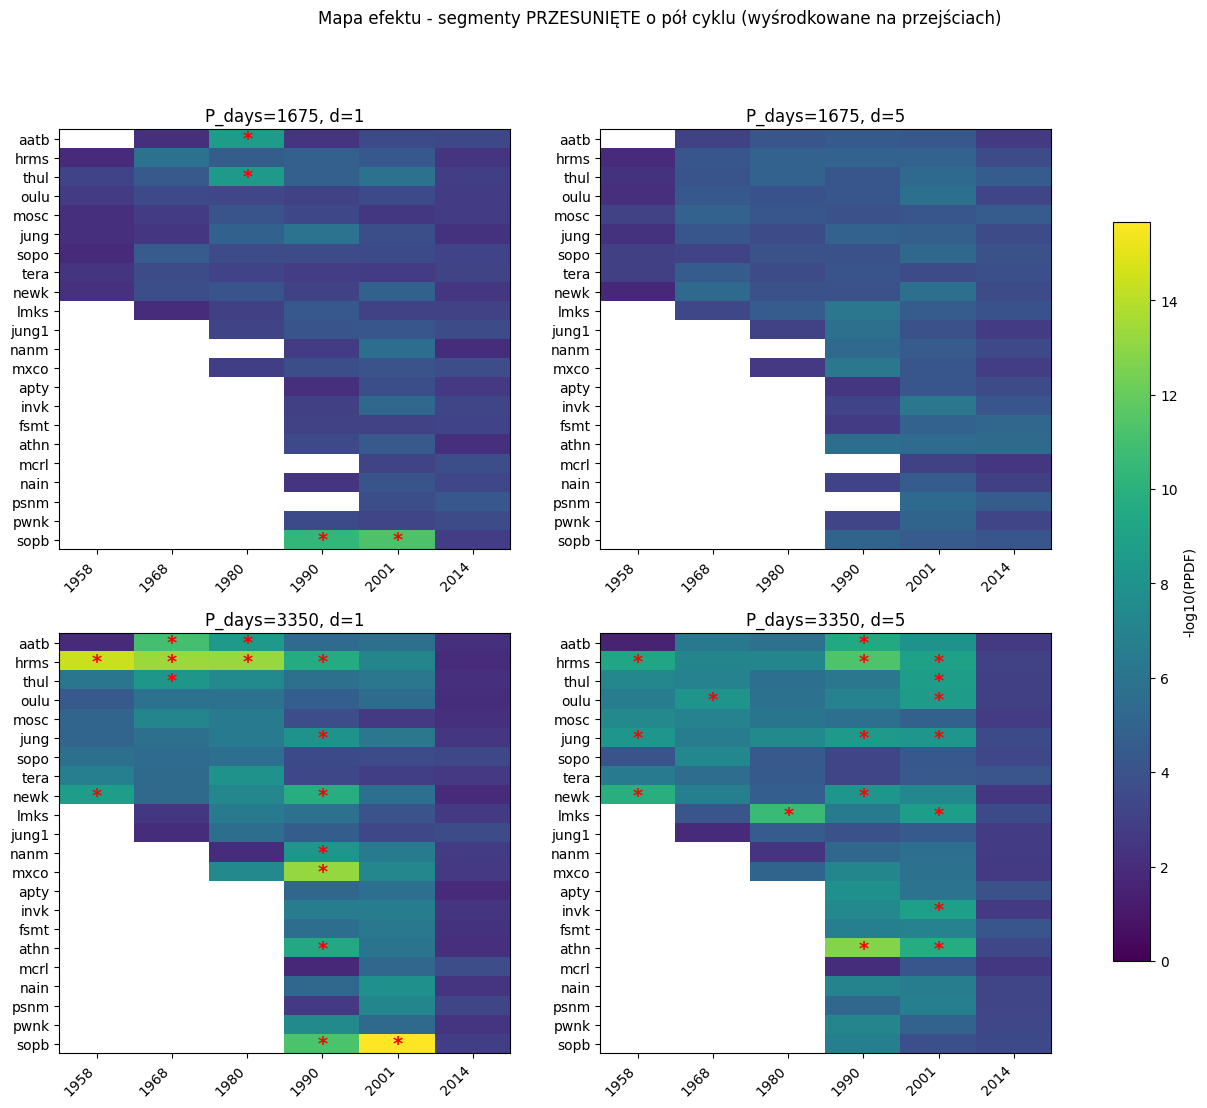

In [9]:
# Mapa na PRZESUNIETYCH segmentach - ten sam styl co 20260822d.ipynb
# (jeden wspolny colorbar, pd.notna() przed bool() zeby nie powtorzyc bledu
# z falszywymi gwiazdkami na pustych komorkach).
if len(shift_summary):
    cycle_order = shift_summary.sort_values("cycle_year")["cycle"].unique()
    station_order = shift_summary.groupby("station")["cycle_year"].nunique().sort_values(ascending=False).index

    vmax = (-shift_summary["log10_PPDF"]).replace([np.inf, -np.inf], np.nan).max()

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    im = None
    for row_i, P_days in enumerate(sorted(shift_summary["P_days"].unique())):
        for col_i, d in enumerate(sorted(shift_summary["d"].unique())):
            ax = axes[row_i][col_i]
            sub = shift_summary[(shift_summary["P_days"] == P_days) & (shift_summary["d"] == d)]
            pivot = sub.pivot(index="station", columns="cycle", values="log10_PPDF").reindex(
                index=station_order, columns=cycle_order)
            beats = sub.pivot(index="station", columns="cycle", values="beats_benchmark").reindex(
                index=station_order, columns=cycle_order)

            im = ax.imshow(-pivot.values, cmap="viridis", aspect="auto", vmin=0, vmax=vmax)
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels([c.replace("shift_", "") for c in pivot.columns], rotation=45, ha="right")
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_title(f"P_days={P_days}, d={d}")
            for yi in range(len(pivot.index)):
                for xi in range(len(pivot.columns)):
                    val = beats.values[yi, xi]
                    if pd.notna(val) and bool(val):
                        ax.text(xi, yi, "*", ha="center", va="center", color="red", fontsize=14, fontweight="bold")
    fig.colorbar(im, ax=axes, label="-log10(PPDF)", shrink=0.8)
    fig.suptitle("Mapa efektu - segmenty PRZESUNIĘTE o pół cyklu (wyśrodkowane na przejściach)")
    fig.savefig(f"{RESULTS_DIR}/cycle_scan_shifted_heatmap.png", dpi=120)
    plt.show()
else:
    print("Brak danych do narysowania mapy.")


In [10]:
# Bezposrednie porownanie: stary podzial (granice=minima, 20260822d.ipynb)
# vs nowy (granice=maksima, ten notebook). Czy przesuniecie SKUPIA sygnal w
# mniej segmentach (silniejszy argument za "efekt zwiazany z przejsciem"),
# czy rozklad "gwiazdek" wyglada tak samo rozproszony jak wczesniej
# (argument za look-elsewhere niezaleznie od sposobu grupowania)?
original_summary = pd.read_csv(f"{RESULTS_DIR}/cycle_scan_summary.csv")

for label, df in [("ORYGINALNY (granice=minima)", original_summary), ("PRZESUNIĘTY (granice=maksima)", shift_summary)]:
    n_beats = int(df["beats_benchmark"].sum())
    n_segments_with_beats = df.loc[df["beats_benchmark"], "cycle"].nunique()
    print(f"{label}: {n_beats} trafien (stacja x segment x P_days x d) w {n_segments_with_beats} segmentach")

print("\nNajsilniejsze wyniki w przesunietym grupowaniu:")
pd.set_option("display.width", 160)
print(shift_summary.sort_values("log10_PPDF").head(10)[
    ["station", "cycle", "P_days", "d", "t0_best", "log10_PPDF"]
].to_string(index=False))


ORYGINALNY (granice=minima): 34 trafien (stacja x segment x P_days x d) w 5 segmentach
PRZESUNIĘTY (granice=maksima): 36 trafien (stacja x segment x P_days x d) w 5 segmentach

Najsilniejsze wyniki w przesunietym grupowaniu:
station      cycle  P_days  d    t0_best  log10_PPDF
   sopb shift_2001    3350  1 2002-05-02  -15.669007
   hrms shift_1958    3350  1 1968-05-26  -14.392060
   hrms shift_1968    3350  1 1968-11-01  -13.295717
   hrms shift_1980    3350  1 1988-08-31  -13.251265
   mxco shift_1990    3350  1 1999-01-19  -13.219248
   athn shift_1990    3350  5 1999-09-02  -12.788865
   hrms shift_1990    3350  5 1998-11-05  -11.351104
   sopb shift_2001    1675  1 2002-08-28  -11.317489
   sopb shift_1990    3350  1 2000-11-29  -11.222696
   aatb shift_1968    3350  1 1978-05-08  -11.065066


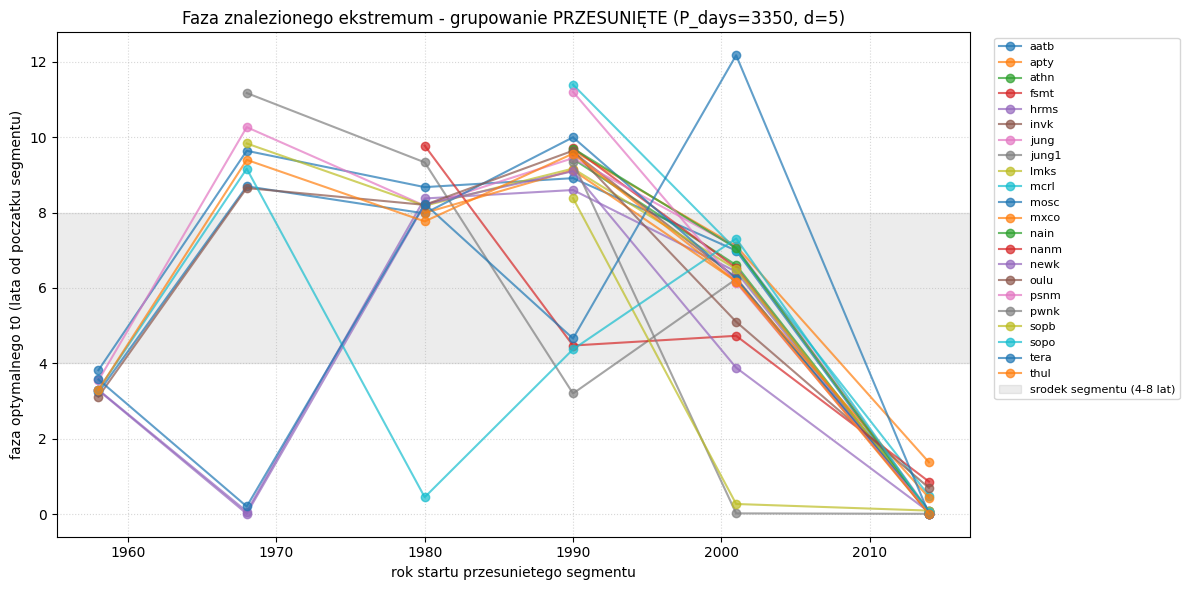

In [11]:
# Wykres FAZY dla PRZESUNIETEGO grupowania (analogiczny do
# 20260822d.ipynb, P_days=3350/d=5) - lata od poczatku PRZESUNIETEGO
# segmentu do znalezionego t0. Jesli hipoteza o przejsciach jest prawdziwa,
# punkty powinny teraz skupiac sie w OKOLICY SRODKA kazdego segmentu (bo
# przejscie jest teraz w srodku, nie na brzegu) - do porownania WPROST z
# oryginalnym wykresem fazy (results/cycle_scan_phase_plot.png), gdzie
# punkty skupialy sie na KRANCACH (2-4 lub 8-12 lat).
segment_starts = {s["label"]: s["start"] for s in shift_segments}
sel = shift_summary[(shift_summary["P_days"] == 3350) & (shift_summary["d"] == 5)].copy()
sel["phase_years"] = sel.apply(
    lambda r: (r["t0_best"] - segment_starts[r["cycle"]]).days / 365.25 if r["cycle"] in segment_starts else np.nan,
    axis=1,
)

fig, ax = plt.subplots(figsize=(12, 6))
for station, g in sel.groupby("station"):
    g = g.sort_values("cycle_year")
    ax.plot(g["cycle_year"], g["phase_years"], "o-", label=station, alpha=0.7)
ax.axhspan(4, 8, color="gray", alpha=0.15, label="srodek segmentu (4-8 lat)")
ax.set_xlabel("rok startu przesunietego segmentu")
ax.set_ylabel("faza optymalnego t0 (lata od poczatku segmentu)")
ax.set_title("Faza znalezionego ekstremum - grupowanie PRZESUNIĘTE (P_days=3350, d=5)")
ax.grid(ls=":", alpha=0.5)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/cycle_scan_shifted_phase_plot.png", dpi=120)
plt.show()


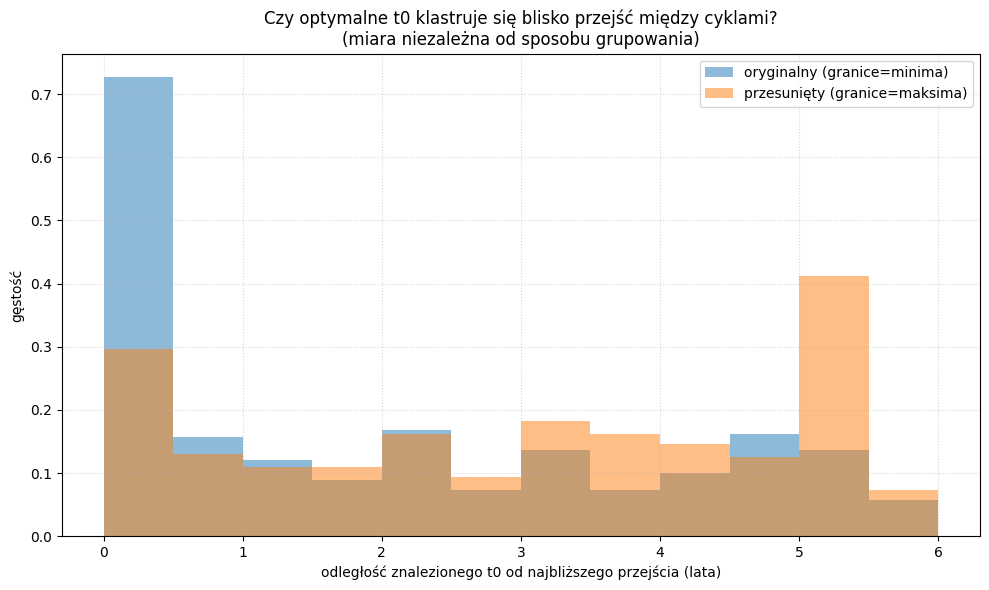

Mediana odległości znalezionego t0 od najbliższego przejścia (lata, im mniej tym bliżej przejścia):
  oryginalny: 1.51 (n=384)
  przesunięty: 3.32 (n=386)

Dla porównania: gdyby t0 byly rozlozone losowo w typowym ~11-letnim cyklu,
oczekiwana mediana odleglosci od najblizszego przejscia (brzegu) wynosilaby ok. 2.75 roku.


In [12]:
# NAJBARDZIEJ BEZPOSREDNI test hipotezy Maćka: zamiast patrzec na faze
# WEWNATRZ dowolnie wybranego binu (co samo w sobie zalezy od wyboru
# granic segmentow), policzmy dla KAZDEGO znalezionego optymalnego t0 (z
# OBU grupowan osobno) odleglosc w latach do NAJBLIZSZEGO prawdziwego
# przejscia (minimum sloneczne, LOWESS jak w 20260822c.ipynb) - miara
# CALKOWICIE niezalezna od jakiegokolwiek binowania/grupowania. Jesli
# klastry realnie leza na przejsciach, obie krzywe (niezaleznie od tego, jak
# pocielismy dane na segmenty) powinny pokazac przewage malych odleglosci.
min_idx, _ = find_peaks(-smoothed, distance=100, prominence=5)
transition_dates = pd.to_datetime(sn["date"].values[min_idx])


def years_to_nearest_transition(t0):
    return np.min(np.abs((t0 - transition_dates).days)) / 365.25


original_summary["years_to_transition"] = pd.to_datetime(original_summary["t0_best"]).apply(years_to_nearest_transition)
shift_summary["years_to_transition"] = pd.to_datetime(shift_summary["t0_best"]).apply(years_to_nearest_transition)

fig, ax = plt.subplots(figsize=(10, 6))
bins = np.arange(0, 6.5, 0.5)
for label, df, color in [
    ("oryginalny (granice=minima)", original_summary, "tab:blue"),
    ("przesunięty (granice=maksima)", shift_summary, "tab:orange"),
]:
    ax.hist(df["years_to_transition"], bins=bins, alpha=0.5, label=label, color=color, density=True)
ax.set_xlabel("odległość znalezionego t0 od najbliższego przejścia (lata)")
ax.set_ylabel("gęstość")
ax.set_title("Czy optymalne t0 klastruje się blisko przejść między cyklami?\n(miara niezależna od sposobu grupowania)")
ax.legend()
ax.grid(ls=":", alpha=0.5)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/cycle_scan_transition_distance_hist.png", dpi=120)
plt.show()

print("Mediana odległości znalezionego t0 od najbliższego przejścia (lata, im mniej tym bliżej przejścia):")
for label, df in [("oryginalny", original_summary), ("przesunięty", shift_summary)]:
    print(f"  {label}: {df['years_to_transition'].median():.2f} (n={len(df)})")
print(f"\nDla porównania: gdyby t0 byly rozlozone losowo w typowym ~11-letnim cyklu,")
print(f"oczekiwana mediana odleglosci od najblizszego przejscia (brzegu) wynosilaby ok. {11/4:.2f} roku.")
